# Modulo 4: CNN de clasificacion con ResNet

Este cuaderno entrena y evalua la CNN sobre los mosaicos temporales generados en el Modulo 3.


## Librerias y parametros del entrenamiento


In [9]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.transforms import InterpolationMode

PROJECT_ROOT = Path.cwd().parent

MANIFEST_PATH = PROJECT_ROOT / "outputs" / "person_windows" / "person_window_manifest.csv"
TRAINING_MANIFEST_OUTPUT_PATH = PROJECT_ROOT / "outputs" / "person_windows" / "person_window_manifest_cnn.csv"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "models"
METRICS_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"

RANDOM_SEED = 21
IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
TOTAL_EPOCHS = 15
HEAD_EPOCHS = 5
LR_HEAD = 1e-3
LR_FINETUNE = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30
PRETRAINED = True
FREEZE_BACKBONE = True
UNFREEZE_LAYER4 = True
EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 4
DEVICE_NAME = "auto"

LABEL_TO_INDEX = {"normal": 0, "hurto_simulado": 1}
INDEX_TO_LABEL = {value: key for key, value in LABEL_TO_INDEX.items()}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

pd.Series(
    {
        "MANIFEST_PATH": str(MANIFEST_PATH),
        "TRAINING_MANIFEST_OUTPUT_PATH": str(TRAINING_MANIFEST_OUTPUT_PATH),
        "IMAGE_SIZE": IMAGE_SIZE,
        "BATCH_SIZE": BATCH_SIZE,
        "TOTAL_EPOCHS": TOTAL_EPOCHS,
        "HEAD_EPOCHS": HEAD_EPOCHS,
        "LR_HEAD": LR_HEAD,
        "LR_FINETUNE": LR_FINETUNE,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "DROPOUT": DROPOUT,
        "PRETRAINED": PRETRAINED,
        "FREEZE_BACKBONE": FREEZE_BACKBONE,
        "UNFREEZE_LAYER4": UNFREEZE_LAYER4,
        "EARLY_STOPPING": EARLY_STOPPING,
        "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
        "DEVICE_NAME": DEVICE_NAME,
    }
)


MANIFEST_PATH                    c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
TRAINING_MANIFEST_OUTPUT_PATH    c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
IMAGE_SIZE                                                                     224
BATCH_SIZE                                                                       8
TOTAL_EPOCHS                                                                    15
HEAD_EPOCHS                                                                      5
LR_HEAD                                                                      0.001
LR_FINETUNE                                                                 0.0001
WEIGHT_DECAY                                                                0.0001
DROPOUT                                                                        0.3
PRETRAINED                                                                    True
FREEZE_BACKBONE                                                               True
UNFR

## Manifest de mosaicos y distribucion por split


In [10]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

manifest_df = pd.read_csv(MANIFEST_PATH)
manifest_df = manifest_df[manifest_df["mosaic_path"].notna()].copy()
manifest_df = manifest_df[manifest_df["mosaic_path"].astype(str) != ""].copy()
if "valid_sample" in manifest_df.columns:
    manifest_df = manifest_df[manifest_df["valid_sample"].astype(str).str.lower() == "true"].copy()
label_column = "source_label" if "source_label" in manifest_df.columns else "class_name"
manifest_df["label_name"] = manifest_df[label_column].astype(str)
manifest_df = manifest_df[manifest_df["label_name"].isin(LABEL_TO_INDEX)].copy()
manifest_df["label_index"] = manifest_df["label_name"].map(LABEL_TO_INDEX).astype(int)
training_manifest_df = manifest_df.sort_values(["split", "sample_id"]).reset_index(drop=True)

training_manifest_df.to_csv(TRAINING_MANIFEST_OUTPUT_PATH, index=False)

split_summary_df = (
    training_manifest_df.groupby(["split", "label_name"])
    .size()
    .reset_index(name="num_samples")
    .sort_values(["split", "label_name"])
    .reset_index(drop=True)
)
split_summary_df


,split,label_name,num_samples
0,test,hurto_simulado,16
1,test,normal,34
2,train,hurto_simulado,61
3,train,normal,89
4,val,hurto_simulado,18
5,val,normal,25


## Transformaciones y registros por split


In [11]:
train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BILINEAR),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

train_records = (
    training_manifest_df[training_manifest_df["split"] == "train"][
        ["sample_id", "label_name", "label_index", "mosaic_path", "split"]
    ]
    .to_dict(orient="records")
)
val_records = (
    training_manifest_df[training_manifest_df["split"] == "val"][
        ["sample_id", "label_name", "label_index", "mosaic_path", "split"]
    ]
    .to_dict(orient="records")
)
test_records = (
    training_manifest_df[training_manifest_df["split"] == "test"][
        ["sample_id", "label_name", "label_index", "mosaic_path", "split"]
    ]
    .to_dict(orient="records")
)

print(f"Train records: {len(train_records)}")
print(f"Val records: {len(val_records)}")
print(f"Test records: {len(test_records)}")

Train records: 150
Val records: 43
Test records: 50


## Un mosaico de referencia


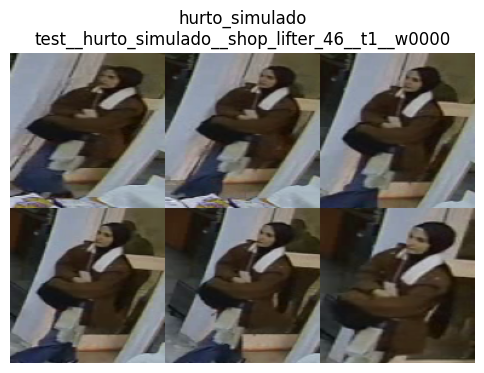

In [12]:
preview_row = training_manifest_df.sort_values(["label_name", "sample_id"]).iloc[0]
preview_path = PROJECT_ROOT / Path(str(preview_row["mosaic_path"]))

with Image.open(preview_path) as preview_image:
    plt.figure(figsize=(6, 6))
    plt.imshow(preview_image.convert("RGB"))
    plt.title(f"{preview_row['label_name']}\n{preview_row['sample_id']}")
    plt.axis("off")
    plt.show()

## Carga de lotes


In [ ]:
train_loader = DataLoader(train_records, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_records, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_records, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

device = torch.device("cuda" if DEVICE_NAME == "auto" and torch.cuda.is_available() else DEVICE_NAME if DEVICE_NAME != "auto" else "cpu")

## ResNet inicial


In [14]:
weights = ResNet50_Weights.DEFAULT if PRETRAINED else None
model = resnet50(weights=weights)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(in_features, 2),
)

if FREEZE_BACKBONE:
    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.fc.parameters():
        parameter.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()

pd.Series(
    {
        "device": str(device),
        "trainable_params_initial": sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad),
    }
)

device                       cpu
trainable_params_initial    4098
dtype: object

## Entrenamiento de la red


In [15]:
history_rows = []
best_val_loss = float("inf")
patience_counter = 0
best_model_path = MODEL_OUTPUT_DIR / "best_model.pt"
last_model_path = MODEL_OUTPUT_DIR / "last_model.pt"
global_epoch = 0

phases = [{"phase_name": "head", "epochs": min(HEAD_EPOCHS, TOTAL_EPOCHS), "lr": LR_HEAD}]
finetune_epochs = max(TOTAL_EPOCHS - min(HEAD_EPOCHS, TOTAL_EPOCHS), 0)
if finetune_epochs > 0:
    phases.append({"phase_name": "finetune", "epochs": finetune_epochs, "lr": LR_FINETUNE})

for phase in phases:
    phase_name = phase["phase_name"]
    phase_epochs = int(phase["epochs"])
    learning_rate = float(phase["lr"])

    if phase_name == "head":
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in model.fc.parameters():
            parameter.requires_grad = True
    elif phase_name == "finetune":
        if UNFREEZE_LAYER4:
            for parameter in model.parameters():
                parameter.requires_grad = False
            for parameter in model.layer4.parameters():
                parameter.requires_grad = True
            for parameter in model.fc.parameters():
                parameter.requires_grad = True
        else:
            for parameter in model.parameters():
                parameter.requires_grad = True

    optimizer = torch.optim.Adam(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )

    for phase_epoch in range(1, phase_epochs + 1):
        global_epoch += 1

        model.train()
        train_losses = []
        train_true = []
        train_pred = []

        for batch in train_loader:
            images = []
            for mosaic_path in batch["mosaic_path"]:
                with Image.open(PROJECT_ROOT / Path(str(mosaic_path))) as image:
                    images.append(train_transform(image.convert("RGB")))
            images = torch.stack(images).to(device)
            labels = batch["label_index"].to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_losses.append(float(loss.detach().cpu().item()))
            train_true.extend(labels.detach().cpu().tolist())
            train_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

        model.eval()
        val_losses = []
        val_true = []
        val_pred = []

        with torch.no_grad():
            for batch in val_loader:
                images = []
                for mosaic_path in batch["mosaic_path"]:
                    with Image.open(PROJECT_ROOT / Path(str(mosaic_path))) as image:
                        images.append(eval_transform(image.convert("RGB")))
                images = torch.stack(images).to(device)
                labels = batch["label_index"].to(device)

                logits = model(images)
                loss = criterion(logits, labels)

                val_losses.append(float(loss.detach().cpu().item()))
                val_true.extend(labels.detach().cpu().tolist())
                val_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

        train_loss = float(np.mean(train_losses)) if train_losses else 0.0
        val_loss = float(np.mean(val_losses)) if val_losses else 0.0

        train_accuracy = float(accuracy_score(train_true, train_pred)) if train_true else 0.0
        train_precision = float(precision_score(train_true, train_pred, zero_division=0)) if train_true else 0.0
        train_recall = float(recall_score(train_true, train_pred, zero_division=0)) if train_true else 0.0
        train_f1 = float(f1_score(train_true, train_pred, zero_division=0)) if train_true else 0.0

        val_accuracy = float(accuracy_score(val_true, val_pred)) if val_true else 0.0
        val_precision = float(precision_score(val_true, val_pred, zero_division=0)) if val_true else 0.0
        val_recall = float(recall_score(val_true, val_pred, zero_division=0)) if val_true else 0.0
        val_f1 = float(f1_score(val_true, val_pred, zero_division=0)) if val_true else 0.0

        history_rows.append(
            {
                "global_epoch": global_epoch,
                "phase_name": phase_name,
                "phase_epoch": phase_epoch,
                "learning_rate": learning_rate,
                "trainable_params": sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad),
                "train_loss": train_loss,
                "train_accuracy": train_accuracy,
                "train_precision": train_precision,
                "train_recall": train_recall,
                "train_f1": train_f1,
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "val_precision": val_precision,
                "val_recall": val_recall,
                "val_f1": val_f1,
            }
        )

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "epoch": global_epoch,
            "phase_name": phase_name,
            "val_metrics": {
                "accuracy": val_accuracy,
                "precision": val_precision,
                "recall": val_recall,
                "f1": val_f1,
                "loss": val_loss,
            },
            "index_to_class": INDEX_TO_LABEL,
            "class_to_index": LABEL_TO_INDEX,
            "training_setup": {
                "manifest_path": str(TRAINING_MANIFEST_OUTPUT_PATH),
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "total_epochs": TOTAL_EPOCHS,
            },
        }
        torch.save(checkpoint, last_model_path)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(checkpoint, best_model_path)
        else:
            patience_counter += 1

        print(
            f"Epoch {global_epoch:02d} | phase={phase_name} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1={val_f1:.4f}"
        )

        if EARLY_STOPPING and patience_counter >= EARLY_STOPPING_PATIENCE:
            print("Early stopping activado.")
            break

    if EARLY_STOPPING and patience_counter >= EARLY_STOPPING_PATIENCE:
        break

history_df = pd.DataFrame(history_rows)
history_df.to_csv(METRICS_OUTPUT_DIR / "train_history.csv", index=False)
history_df

Epoch 01 | phase=head | train_loss=0.6613 | val_loss=0.5778 | val_f1=0.7143
Epoch 02 | phase=head | train_loss=0.5391 | val_loss=0.5066 | val_f1=0.6154
Epoch 03 | phase=head | train_loss=0.4583 | val_loss=0.5059 | val_f1=0.4348
Epoch 04 | phase=head | train_loss=0.4481 | val_loss=0.4881 | val_f1=0.5000
Epoch 05 | phase=head | train_loss=0.3829 | val_loss=0.5038 | val_f1=0.3636
Epoch 06 | phase=finetune | train_loss=0.3770 | val_loss=0.3990 | val_f1=0.6897
Epoch 07 | phase=finetune | train_loss=0.2353 | val_loss=0.4267 | val_f1=0.6154
Epoch 08 | phase=finetune | train_loss=0.1770 | val_loss=0.4034 | val_f1=0.6154
Epoch 09 | phase=finetune | train_loss=0.0979 | val_loss=0.3872 | val_f1=0.7333
Epoch 10 | phase=finetune | train_loss=0.0903 | val_loss=0.3487 | val_f1=0.7879
Epoch 11 | phase=finetune | train_loss=0.0738 | val_loss=0.6436 | val_f1=0.4000
Epoch 12 | phase=finetune | train_loss=0.0682 | val_loss=0.4195 | val_f1=0.5600
Epoch 13 | phase=finetune | train_loss=0.0512 | val_loss=0.3

,global_epoch,phase_name,phase_epoch,learning_rate,trainable_params,train_loss,train_accuracy,train_precision,train_recall,train_f1,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,head,1,0.0010,4098,0.661287,0.580000,0.416667,0.081967,0.136986,0.577833,0.813953,1.000000,0.555556,0.714286
1,2,head,2,0.0010,4098,0.539051,0.766667,0.696970,0.754098,0.724409,0.506550,0.767442,1.000000,0.444444,0.615385
2,3,head,3,0.0010,4098,0.458288,0.846667,0.851852,0.754098,0.800000,0.505901,0.697674,1.000000,0.277778,0.434783
3,4,head,4,0.0010,4098,0.448111,0.800000,0.829787,0.639344,0.722222,0.488087,0.720930,1.000000,0.333333,0.500000
4,5,head,5,0.0010,4098,0.382921,0.873333,0.818182,0.885246,0.850394,0.503833,0.674419,1.000000,0.222222,0.363636
5,6,finetune,1,0.0001,14968834,0.376972,0.840000,0.768116,0.868852,0.815385,0.398967,0.790698,0.909091,0.555556,0.689655
6,7,finetune,2,0.0001,14968834,0.235257,0.953333,0.935484,0.950820,0.943089,0.426724,0.767442,1.000000,0.444444,0.615385
7,8,finetune,3,0.0001,14968834,0.177010,0.926667,0.903226,0.918033,0.910569,0.403380,0.767442,1.000000,0.444444,0.615385
8,9,finetune,4,0.0001,14968834,0.097903,0.993333,1.000000,0.983607,0.991736,0.387190,0.813953,0.916667,0.611111,0.733333
9,10,finetune,5,0.0001,14968834,0.090294,0.993333,1.000000,0.983607,0.991736,0.348712,0.837209,0.866667,0.722222,0.787879


## Evolucion de la pérdida


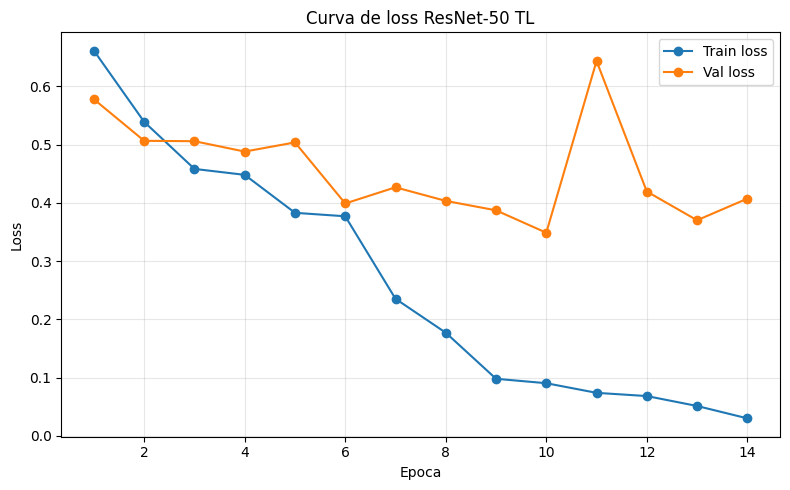

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["global_epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["global_epoch"], history_df["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Curva de loss ResNet-50 TL")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_OUTPUT_DIR / "loss_curve.png", dpi=150)
plt.show()

## Desempeño final en test


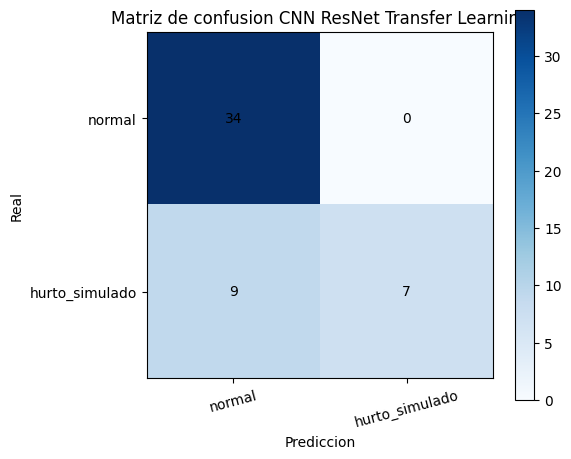

{'accuracy': 0.82,
 'precision': 1.0,
 'recall': 0.4375,
 'f1': 0.6086956521739131,
 'num_test_samples': 50,
 'model_path': 'c:\\Users\\franco\\Downloads\\1-INTELIGENCIA_ARTIFICIAL\\PROJECT\\ENTREGA_2\\outputs\\models\\best_model.pt'}

In [18]:
checkpoint_data = torch.load(MODEL_OUTPUT_DIR / "best_model.pt", map_location=device)
eval_model = resnet50(weights=None)
in_features = eval_model.fc.in_features
eval_model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(in_features, 2),
)
eval_model.load_state_dict(checkpoint_data["model_state_dict"])
eval_model = eval_model.to(device)
eval_model.eval()

test_true = []
test_pred = []

with torch.no_grad():
    for batch in test_loader:
        images = []
        for mosaic_path in batch["mosaic_path"]:
            with Image.open(PROJECT_ROOT / Path(str(mosaic_path))) as image:
                images.append(eval_transform(image.convert("RGB")))
        images = torch.stack(images).to(device)
        labels = batch["label_index"].to(device)
        logits = eval_model(images)
        predictions = torch.argmax(logits, dim=1)
        test_true.extend(labels.detach().cpu().tolist())
        test_pred.extend(predictions.detach().cpu().tolist())

test_metrics = {
    "accuracy": float(accuracy_score(test_true, test_pred)) if test_true else 0.0,
    "precision": float(precision_score(test_true, test_pred, zero_division=0)) if test_true else 0.0,
    "recall": float(recall_score(test_true, test_pred, zero_division=0)) if test_true else 0.0,
    "f1": float(f1_score(test_true, test_pred, zero_division=0)) if test_true else 0.0,
    "num_test_samples": int(len(test_true)),
    "model_path": str(MODEL_OUTPUT_DIR / "best_model.pt"),
}

test_confusion = confusion_matrix(test_true, test_pred, labels=[0, 1]) if test_true else np.zeros((2, 2), dtype=int)
(METRICS_OUTPUT_DIR / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")

plt.figure(figsize=(6, 5))
plt.imshow(test_confusion, cmap="Blues")
plt.title("Matriz de confusion CNN ResNet Transfer Learning")
plt.colorbar()
plt.xticks([0, 1], [INDEX_TO_LABEL[0], INDEX_TO_LABEL[1]], rotation=15)
plt.yticks([0, 1], [INDEX_TO_LABEL[0], INDEX_TO_LABEL[1]])
plt.xlabel("Prediccion")
plt.ylabel("Real")
for row_index in range(test_confusion.shape[0]):
    for col_index in range(test_confusion.shape[1]):
        plt.text(col_index, row_index, str(int(test_confusion[row_index, col_index])), ha="center", va="center", color="black")
plt.tight_layout()
plt.savefig(FIGURES_OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

test_metrics

## Artefactos del modulo


In [19]:
artifact_paths = [
    MODEL_OUTPUT_DIR / "best_model.pt",
    MODEL_OUTPUT_DIR / "last_model.pt",
    METRICS_OUTPUT_DIR / "train_history.csv",
    METRICS_OUTPUT_DIR / "test_metrics.json",
    FIGURES_OUTPUT_DIR / "loss_curve.png",
    FIGURES_OUTPUT_DIR / "confusion_matrix.png",
]
pd.DataFrame({"artifact": [str(path) for path in artifact_paths], "exists": [path.exists() for path in artifact_paths]})

,artifact,exists
0,c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...,True
1,c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...,True
2,c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...,True
3,c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...,True
4,c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...,True
5,c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...,True
